In [1]:
import nilmtk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nilmtk import DataSet

print(f"NILMTK version: {nilmtk.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

NILMTK version: 0.4.0.dev1+git.1b324df
pandas version: 2.2.3
numpy version: 2.4.5


In [2]:
from pathlib import Path

data_dir = Path("../data")
for f in ["ukdale.h5", "redd.h5"]:
    path = data_dir / f
    if path.exists():
        size_gb = path.stat().st_size / 1e9
        print(f"✅ {path} → {size_gb:.2f} Go")
    else:
        print(f"❌ {path} introuvable")

✅ ..\data\ukdale.h5 → 6.33 Go
✅ ..\data\redd.h5 → 0.40 Go


In [3]:
ukdale = DataSet("../data/ukdale.h5")
redd = DataSet("../data/redd.h5")

print("\n=== UK-DALE ===")
for house_id in sorted(ukdale.buildings.keys()):
    elec = ukdale.buildings[house_id].elec
    tf = elec.mains().get_timeframe()
    n_appliances = len(elec.appliances)
    print(f"  house_{house_id}: {tf.start.date()} → {tf.end.date()} | {n_appliances} appareils")

print("\n=== REDD ===")
for house_id in sorted(redd.buildings.keys()):
    elec = redd.buildings[house_id].elec
    tf = elec.mains().get_timeframe()
    n_appliances = len(elec.appliances)
    print(f"  house_{house_id}: {tf.start.date()} → {tf.end.date()} | {n_appliances} appareils")


=== UK-DALE ===
  house_1: 2013-03-17 → 2017-04-26 | 72 appareils
  house_2: 2013-04-16 → 2013-10-10 | 18 appareils
  house_3: 2013-02-27 → 2013-04-08 | 4 appareils
  house_4: 2013-03-09 → 2013-10-01 | 11 appareils
  house_5: 2014-06-29 → 2014-11-13 | 24 appareils

=== REDD ===
  house_1: 2011-04-18 → 2011-05-24 | 16 appareils
  house_2: 2011-04-17 → 2011-05-22 | 9 appareils
  house_3: 2011-04-16 → 2011-05-30 | 19 appareils
  house_4: 2011-04-16 → 2011-06-03 | 17 appareils
  house_5: 2011-04-18 → 2011-05-31 | 22 appareils
  house_6: 2011-05-21 → 2011-06-14 | 14 appareils


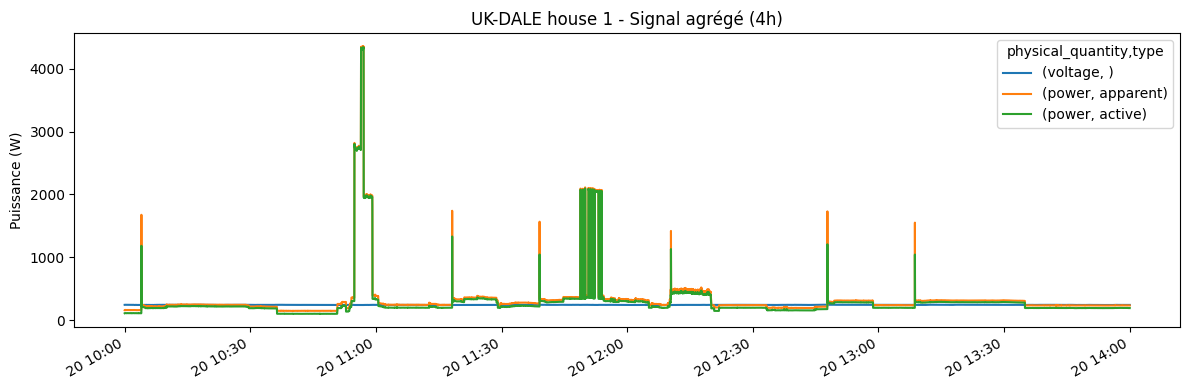

In [ ]:
# UK-DALE house 1, 4 heures de mains
ukdale.set_window(start="2014-04-20 10:00", end="2014-04-20 14:00")
mains_uk = next(ukdale.buildings[1].elec.mains().load())

fig, ax = plt.subplots(figsize=(12, 4))
mains_uk.plot(ax=ax)
ax.set_title("UK-DALE house 1 - Signal agrégé (4h)")
ax.set_ylabel("Puissance (W)")
plt.tight_layout()
plt.show()